In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import time
import warnings
import gc
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings('ignore')



## Data Loading and Train/Test Split

In [2]:
DATA_PATH = r"C:\Users\LENOVO\Downloads\milan_data"
MATRIX_PATH = os.path.join(DATA_PATH, 'traffic_matrix.parquet')

# Load traffic matrix
print("Loading traffic matrix...")
traffic_matrix = pd.read_parquet(MATRIX_PATH)

with open(os.path.join(DATA_PATH, 'task2_checkpoint.pkl'), 'rb') as f:
    checkpoint = pickle.load(f)

target_areas = checkpoint['target_areas']
highest_area = checkpoint['highest_area']

print(f"Traffic matrix shape: {traffic_matrix.shape}")
print(f"Target areas: {target_areas}")
print(f"Date range: {traffic_matrix.index.min()} to {traffic_matrix.index.max()}")

# Define train/test split
test_start  = '2013-12-16'
test_end    = '2013-12-22 23:50:00'

print(f"\nTrain: {traffic_matrix.index.min()}")
print(f"Test:  {test_start} to {test_end}")
print(f"Test periods: {len(traffic_matrix[test_start:test_end])} intervals")

Loading traffic matrix...
Traffic matrix shape: (8928, 10000)
Target areas: [5161, 4159, 4556]
Date range: 2013-10-31 23:00:00 to 2014-01-01 22:50:00

Train: 2013-10-31 23:00:00
Test:  2013-12-16 to 2013-12-22 23:50:00
Test periods: 1008 intervals


We load the preprocessed traffic matrix from Task 2 and define
our train/test split for forecasting.

Train set: All data from October 31 to December 15, 2013

Test set: December 16-22, 2013 (one full week)

Target areas loaded:
- Area 5161 : Highest traffic (city center)
- Area 4159 : Moderate traffic (residential)
- Area 4556 : High traffic (entertainment district)

##  Helper Functions

In [3]:
def evaluate_model(y_true, y_pred, model_name, area):
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    
    print(f"\n{model_name} - Area {area}:")
    print(f"  MAE:  {mae:>10.4f}")
    print(f"  MAPE: {mape:>10.4f}%")
    print(f"  RMSE: {rmse:>10.4f}")
    
    return {'MAE': mae, 'MAPE': mape, 'RMSE': rmse}


def plot_predictions(y_true, y_pred, area, model_name, test_index):
    """Plot actual vs predicted traffic"""
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    
    # Full week plot
    axes[0].plot(test_index, y_true, 
                 color='steelblue', linewidth=1, label='Actual', alpha=0.8)
    axes[0].plot(test_index, y_pred,
                 color='red', linewidth=1, label='Predicted', alpha=0.8)
    axes[0].set_title(f'{model_name} - Area {area} | Dec 16-22 2013')
    axes[0].set_ylabel('Internet Traffic')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Zoom into first 2 days
    axes[1].plot(test_index[:288], y_true[:288],
                 color='steelblue', linewidth=1, label='Actual', alpha=0.8)
    axes[1].plot(test_index[:288], y_pred[:288],
                 color='red', linewidth=1, label='Predicted', alpha=0.8)
    axes[1].set_title(f'{model_name} - Area {area} | First 2 Days (Zoomed)')
    axes[1].set_ylabel('Internet Traffic')
    axes[1].set_xlabel('Date')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    filename = f'task3_{model_name.lower().replace(" ","_")}_area{area}.png'
    plt.savefig(os.path.join(DATA_PATH, filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved: {filename}")


def prepare_series(area):
    """Get train and test series for an area"""
    series = traffic_matrix[area]
    train = series[series.index < test_start]
    test  = series[test_start:test_end]
    return train, test


print("Helper functions defined!")
print(f"\nQuick data check:")
for area in target_areas:
    train, test = prepare_series(area)
    print(f"Area {area}: train={len(train):,}  test={len(test):,}")

Helper functions defined!

Quick data check:
Area 5161: train=6,486  test=1,008
Area 4159: train=6,486  test=1,008
Area 4556: train=6,486  test=1,008


We define two reusable helper functions used across all three models:
Plots actual vs predicted traffic for the test week (Dec 16-22),
with a zoomed view of the first 2 days for detailed inspection.

Splits any area's time series into train and test sets using
the defined cutoff date of December 16, 2013.

All three target areas have identical split sizes:
- Train: 6,486 intervals (~45 days)
- Test: 1,008 intervals (exactly 7 days)

## Model 1: SARIMA

Found saved SARIMA results, loading...
Loaded!
SARIMA RESULTS

SARIMA - Area 5161:
  MAE:    354.6968
  MAPE:    20.1647%
  RMSE:   669.7481
  Train time: 1146.7s
  Pred time:  2.2s


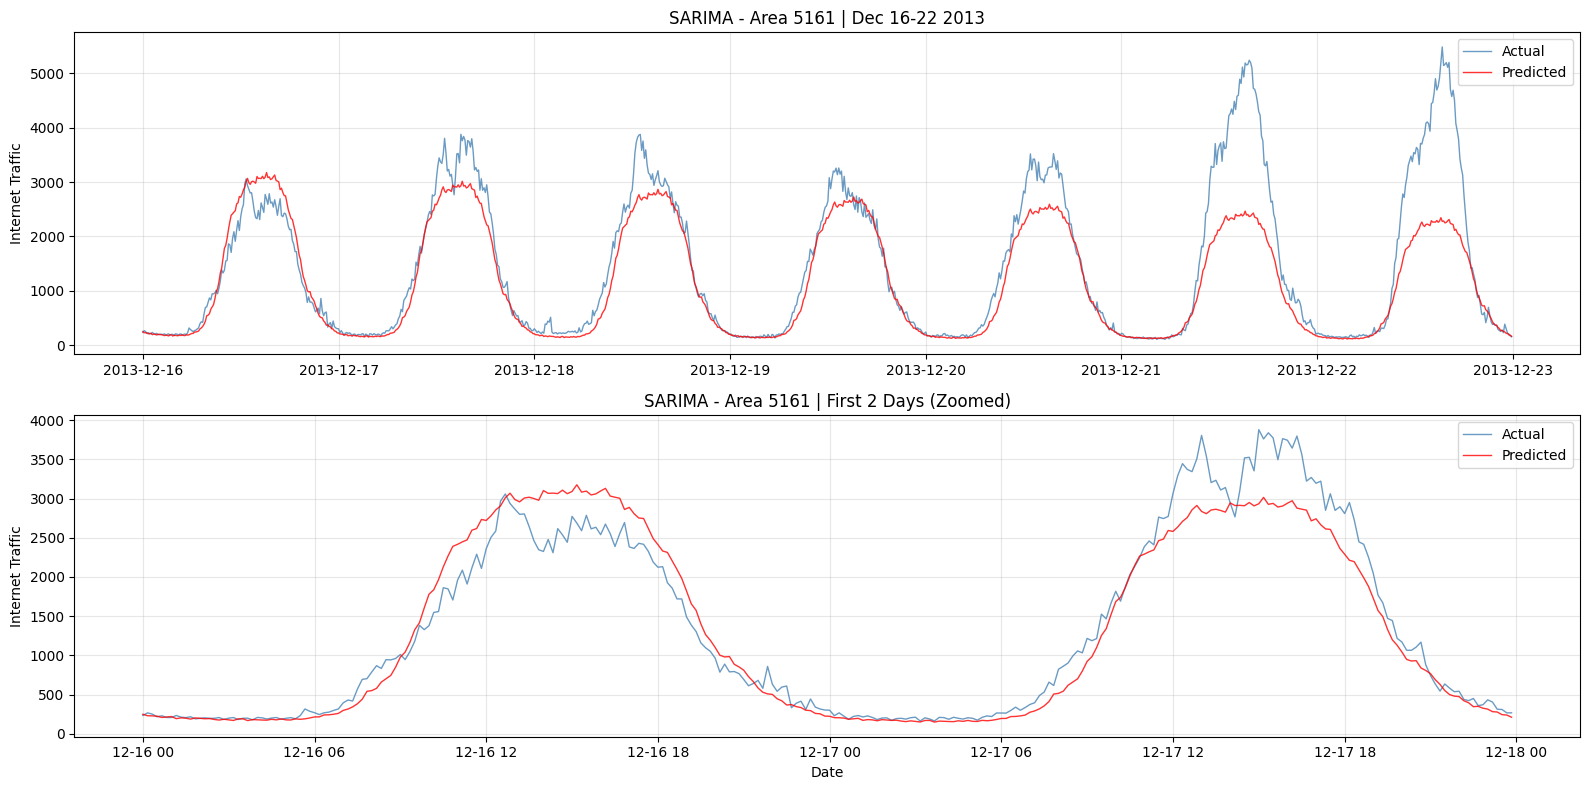

Plot saved: task3_sarima_area5161.png

SARIMA - Area 4159:
  MAE:    168.2972
  MAPE:    66.9520%
  RMSE:   195.8992
  Train time: 1078.7s
  Pred time:  2.1s


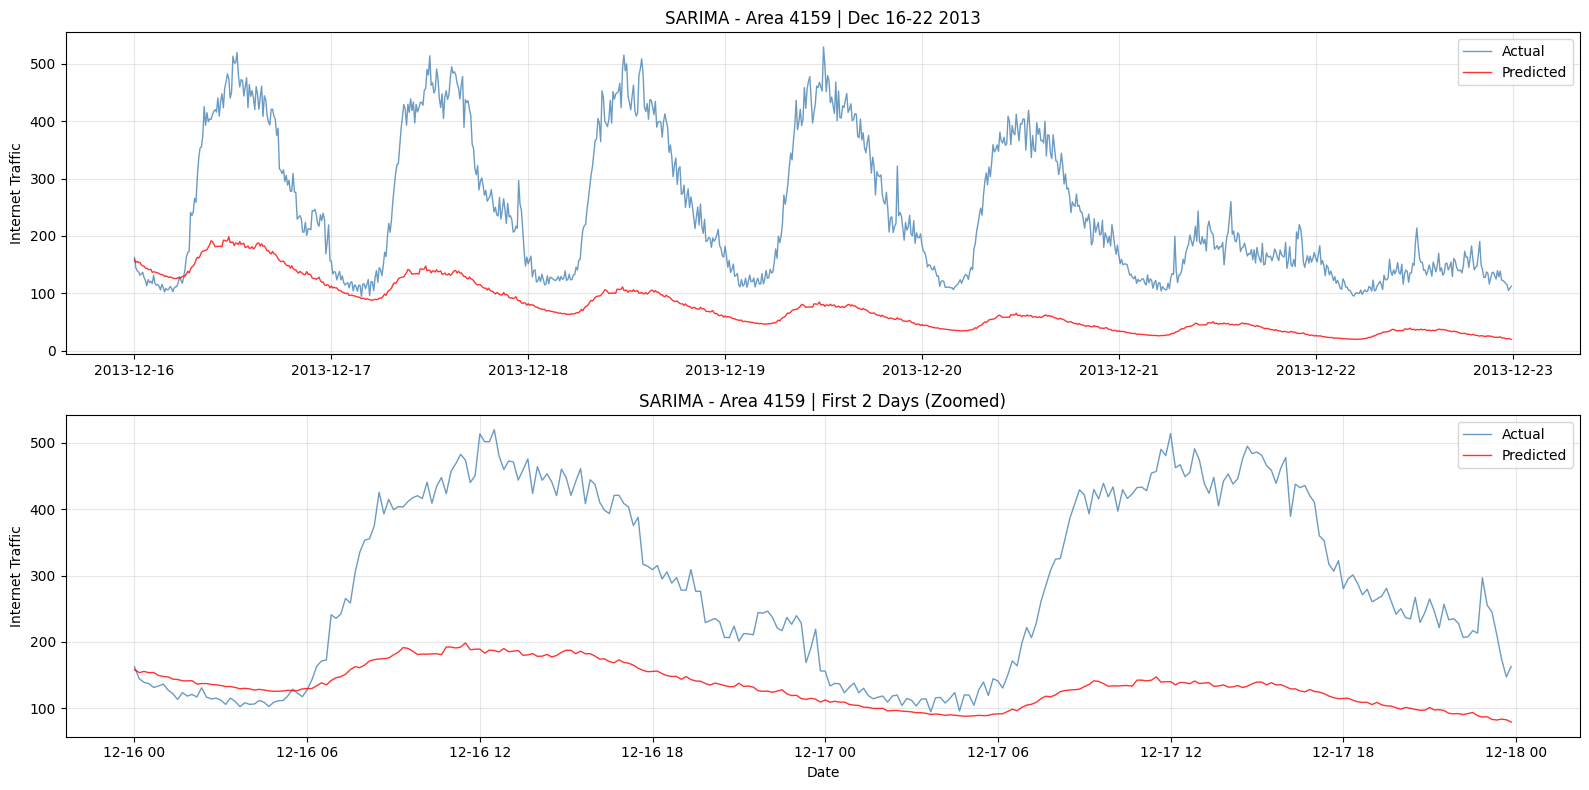

Plot saved: task3_sarima_area4159.png

SARIMA - Area 4556:
  MAE:    330.4745
  MAPE:    68.9532%
  RMSE:   377.1503
  Train time: 687.6s
  Pred time:  2.9s


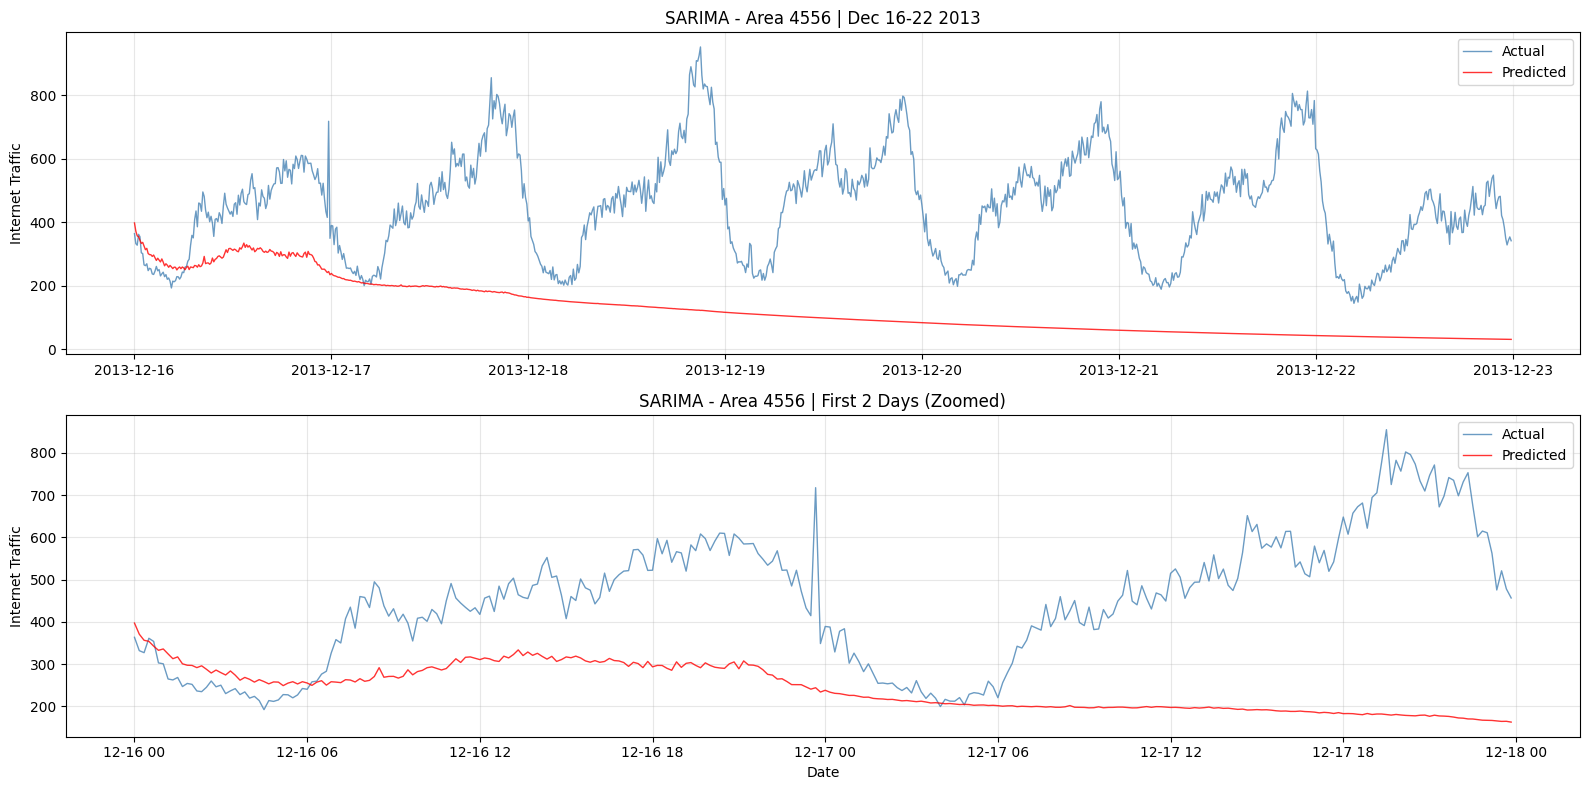

Plot saved: task3_sarima_area4556.png


In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

SARIMA_PATH = os.path.join(DATA_PATH, 'sarima_results.pkl')

if os.path.exists(SARIMA_PATH):
    print("Found saved SARIMA results, loading...")
    with open(SARIMA_PATH, 'rb') as f:
        sarima_results = pickle.load(f)
    print("Loaded!")

else:
    sarima_results = {}
    
    for area in target_areas:
        print(f"\nFitting SARIMA for Area {area}...")
        train, test = prepare_series(area)
        
        # Use last 2 weeks of train for speed
        train_sarima = train[-2016:]
        
        start_time = time.time()
        
        model = SARIMAX(
            train_sarima,
            order=(1, 0, 1),
            seasonal_order=(1, 0, 1, 144),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        print(f"Fitting model")
        fitted = model.fit(disp=False, maxiter=50)
        train_time = time.time() - start_time
        
        print(f"  Forecasting {len(test)} steps...")
        start_pred = time.time()
        forecast = fitted.forecast(steps=len(test))
        pred_time = time.time() - start_pred
        
        forecast = np.clip(forecast.values, 0, None)
        
        sarima_results[area] = {
            'predictions': forecast,
            'train_time': train_time,
            'pred_time': pred_time,
            'aic': fitted.aic,
            'model_order': '(1,0,1)(1,0,1,144)'
        }
        
    
    with open(SARIMA_PATH, 'wb') as f:
        pickle.dump(sarima_results, f)


# Evaluate and plot
print("SARIMA RESULTS")
sarima_metrics = {}
for area in target_areas:
    train, test = prepare_series(area)
    preds = sarima_results[area]['predictions']
    
    metrics = evaluate_model(test.values, preds, 'SARIMA', area)
    sarima_metrics[area] = metrics
    
    print(f"  Train time: {sarima_results[area]['train_time']:.1f}s")
    print(f"  Pred time:  {sarima_results[area]['pred_time']:.1f}s")
    
    plot_predictions(test.values, preds, area, 'SARIMA', test.index)

SARIMA performed best on Area 5161 (lowest MAPE) but struggled 
with Areas 4159 and 4556 due to their irregular spike patterns.
Prediction time was under 3 seconds for all areas.

In [5]:
import os
SARIMA_PATH = os.path.join(DATA_PATH, 'sarima_results.pkl')
print(f"SARIMA file exists: {os.path.exists(SARIMA_PATH)}")

if os.path.exists(SARIMA_PATH):
    import pickle
    with open(SARIMA_PATH, 'rb') as f:
        sarima_results = pickle.load(f)
    print(f"Areas saved: {list(sarima_results.keys())}")
    for area, res in sarima_results.items():
        print(f"  Area {area}: {len(res['predictions'])} predictions, train_time={res['train_time']:.1f}s")
else:
    print("NOT saved ,  need to rerun!")

SARIMA file exists: True
Areas saved: [5161, 4159, 4556]
  Area 5161: 1008 predictions, train_time=1146.7s
  Area 4159: 1008 predictions, train_time=1078.7s
  Area 4556: 1008 predictions, train_time=687.6s


In [7]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


TensorFlow version: 2.21.0

Training LSTM for Area 5161...
Epoch 1/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 22s 100ms/step - loss: 0.0054 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - loss: 0.0020 - val_loss: 9.1500e-04 - learning_rate: 0.0010
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - loss: 0.0016 - val_loss: 9.1246e-04 - learning_rate: 0.0010
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - loss: 0.0014 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - loss: 0.0014 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - loss: 0.0013 - val_loss: 5.9135e-04 - learning_rate: 5.0000e-04
Epoch 7/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - loss: 0.0012 - val_loss: 6.1205e-04 - learning_rate: 5.0000e-04
Epoch 8/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - loss: 0.0012 - val_loss: 5.6041e-04 - learning_rate: 5.0000e-04
Epoch 9/3

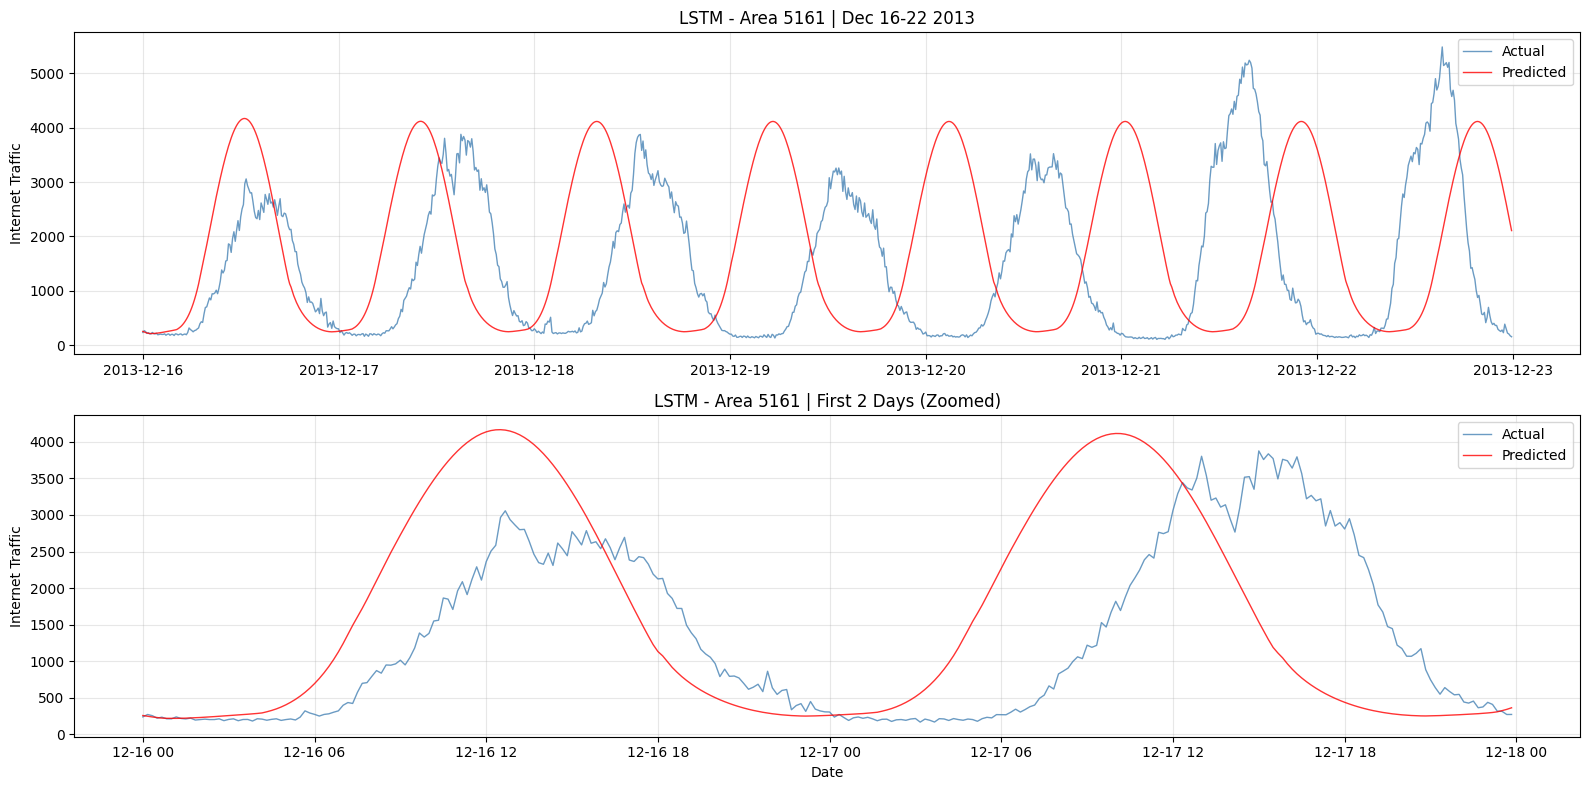

Plot saved: task3_lstm_area5161.png

LSTM - Area 4159:
  MAE:    112.3127
  MAPE:    35.6300%
  RMSE:   158.5973
  Train time: 312.2s
  Pred time:  155.9s


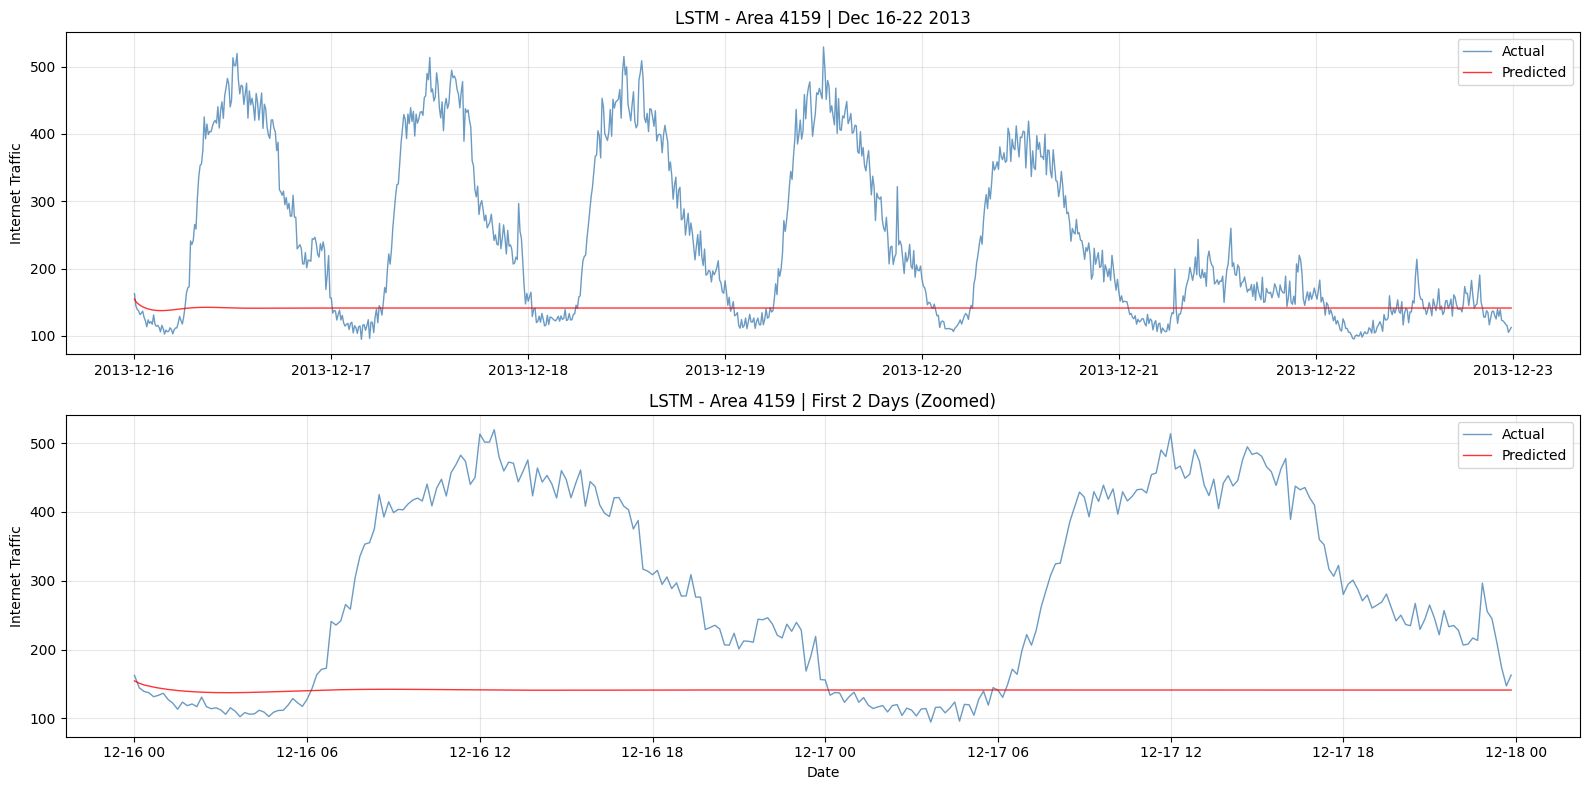

Plot saved: task3_lstm_area4159.png

LSTM - Area 4556:
  MAE:    204.3014
  MAPE:    64.9622%
  RMSE:   240.9394
  Train time: 620.9s
  Pred time:  147.4s


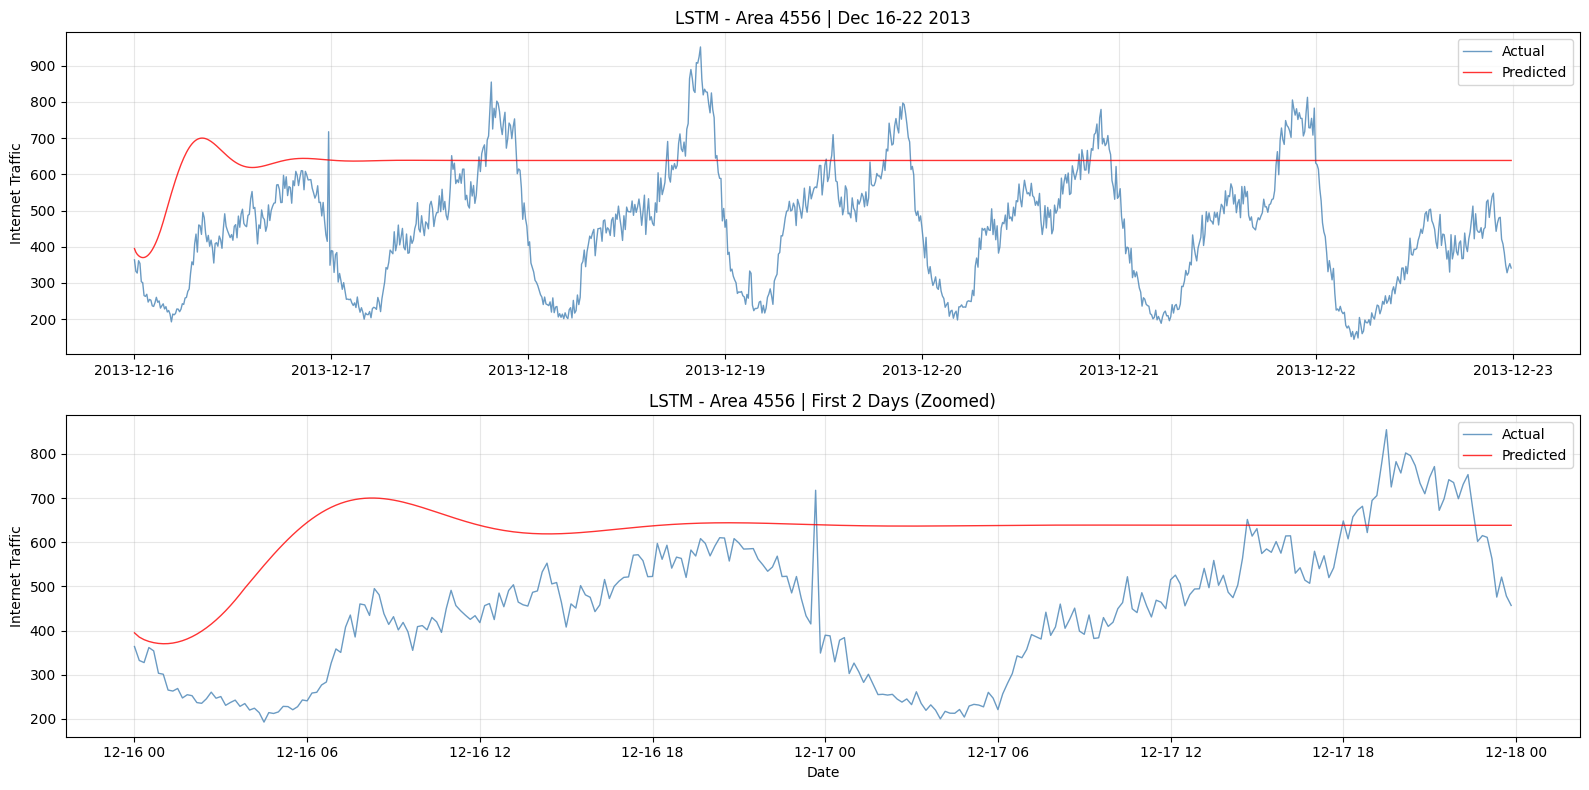

Plot saved: task3_lstm_area4556.png


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

LSTM_PATH = os.path.join(DATA_PATH, 'lstm_results.pkl')

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 144

if os.path.exists(LSTM_PATH):
    print("Found saved LSTM results, loading...")
    with open(LSTM_PATH, 'rb') as f:
        lstm_results = pickle.load(f)
    print("Loaded!")

else:
    lstm_results = {}
    
    for area in target_areas:
        print(f"\nTraining LSTM for Area {area}...")
        train, test = prepare_series(area)
        
        # Normalize
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
        
        # Create sequences
        X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
        X_train = X_train.reshape(X_train.shape[0], SEQ_LEN, 1)
        
        # Build model
        model = Sequential([
            LSTM(64, return_sequences=True,
                 input_shape=(SEQ_LEN, 1)),
            Dropout(0.2),
            LSTM(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        
        model.compile(optimizer='adam', loss='mse')
        
        callbacks = [
            EarlyStopping(patience=5, restore_best_weights=True),
            ReduceLROnPlateau(factor=0.5, patience=3)
        ]
        
        start_time = time.time()
        history = model.fit(
            X_train, y_train,
            epochs=30,          
            batch_size=32,
            validation_split=0.1,
            callbacks=callbacks,
            verbose=1
        )
        train_time = time.time() - start_time
        
        # Rolling forecast
        print(f"  Forecasting {len(test)} steps...")
        start_pred = time.time()
        
        predictions = []
        current_seq = train_scaled[-SEQ_LEN:].copy()
        
        for _ in range(len(test)):
            x_input = current_seq.reshape(1, SEQ_LEN, 1)
            pred = model.predict(x_input, verbose=0)[0,0]
            predictions.append(pred)
            current_seq = np.roll(current_seq, -1)
            current_seq[-1] = pred
        
        pred_time = time.time() - start_pred
        
        # Inverse transform
        predictions = scaler.inverse_transform(
            np.array(predictions).reshape(-1,1)
        ).flatten()
        predictions = np.clip(predictions, 0, None)
        
        lstm_results[area] = {
            'predictions': predictions,
            'train_time': train_time,
            'pred_time': pred_time,
            'history': history.history
        }
        
        print(f"  Done! Train time: {train_time:.1f}s")
        
        model.save_weights(os.path.join(DATA_PATH, f'lstm_weights_area{area}.weights.h5'))
        
        del model
        gc.collect()
    
    with open(LSTM_PATH, 'wb') as f:
        pickle.dump(lstm_results, f)


print("LSTM RESULTS")

lstm_metrics = {}
for area in target_areas:
    train, test = prepare_series(area)
    preds = lstm_results[area]['predictions']
    
    metrics = evaluate_model(test.values, preds, 'LSTM', area)
    lstm_metrics[area] = metrics
    
    print(f"  Train time: {lstm_results[area]['train_time']:.1f}s")
    print(f"  Pred time:  {lstm_results[area]['pred_time']:.1f}s")
    
    plot_predictions(test.values, preds, area, 'LSTM', test.index)



Training Transformer for Area 5161...
Epoch 1/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - loss: 0.0435 - val_loss: 0.0417 - learning_rate: 0.0010
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - loss: 0.0318 - val_loss: 0.0418 - learning_rate: 0.0010
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - loss: 0.0306 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - loss: 0.0305 - val_loss: 0.0457 - learning_rate: 0.0010
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - loss: 0.0301 - val_loss: 0.0491 - learning_rate: 5.0000e-04
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - loss: 0.0310 - val_loss: 0.0416 - learning_rate: 5.0000e-04
Epoch 7/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - loss: 0.0304 - val_loss: 0.0419 - learning_rate: 5.0000e-04
Epoch 8/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - loss: 0.0310 - val_loss: 0.0430 - learning_rate: 5.0000e-04
Epoch 9/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/

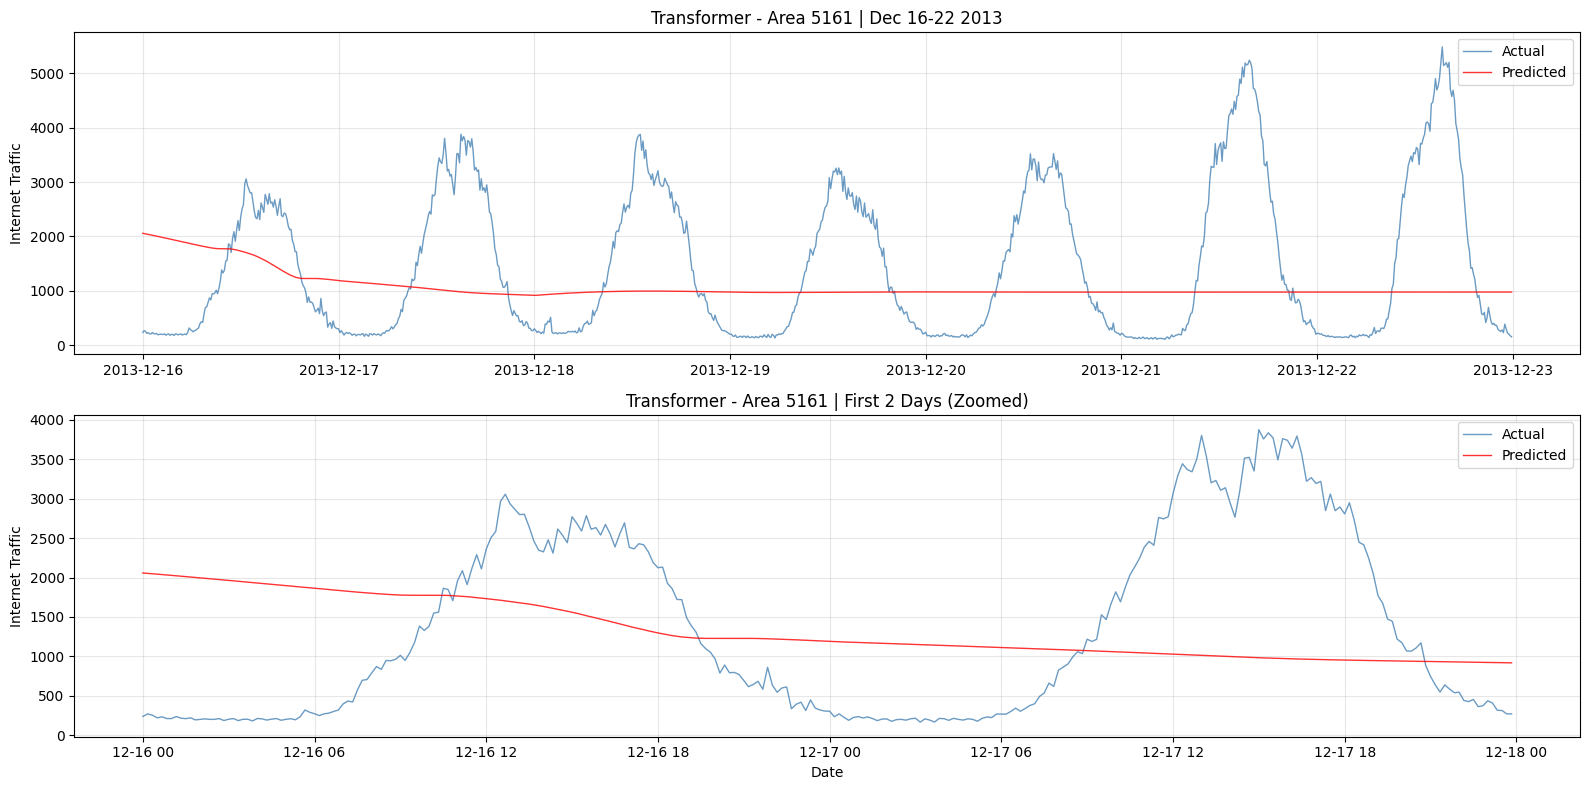

Plot saved: task3_transformer_area5161.png

Transformer - Area 4159:
  MAE:    113.2999
  MAPE:    36.1006%
  RMSE:   159.1934
  Train time: 215.1s
  Pred time:  195.3s


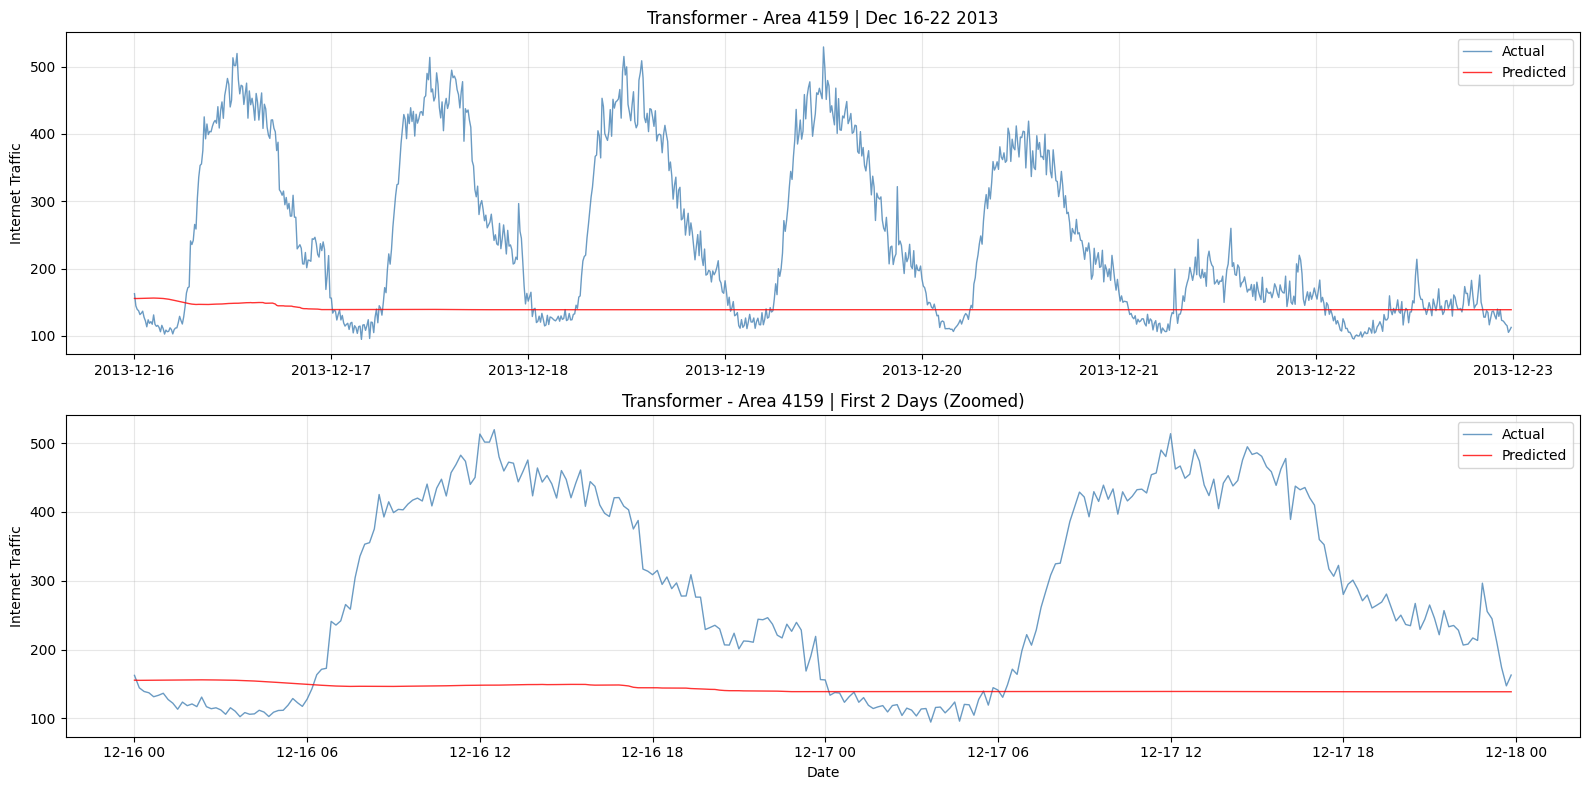

Plot saved: task3_transformer_area4159.png

Transformer - Area 4556:
  MAE:    252.0768
  MAPE:    79.0391%
  RMSE:   290.0451
  Train time: 103.1s
  Pred time:  197.6s


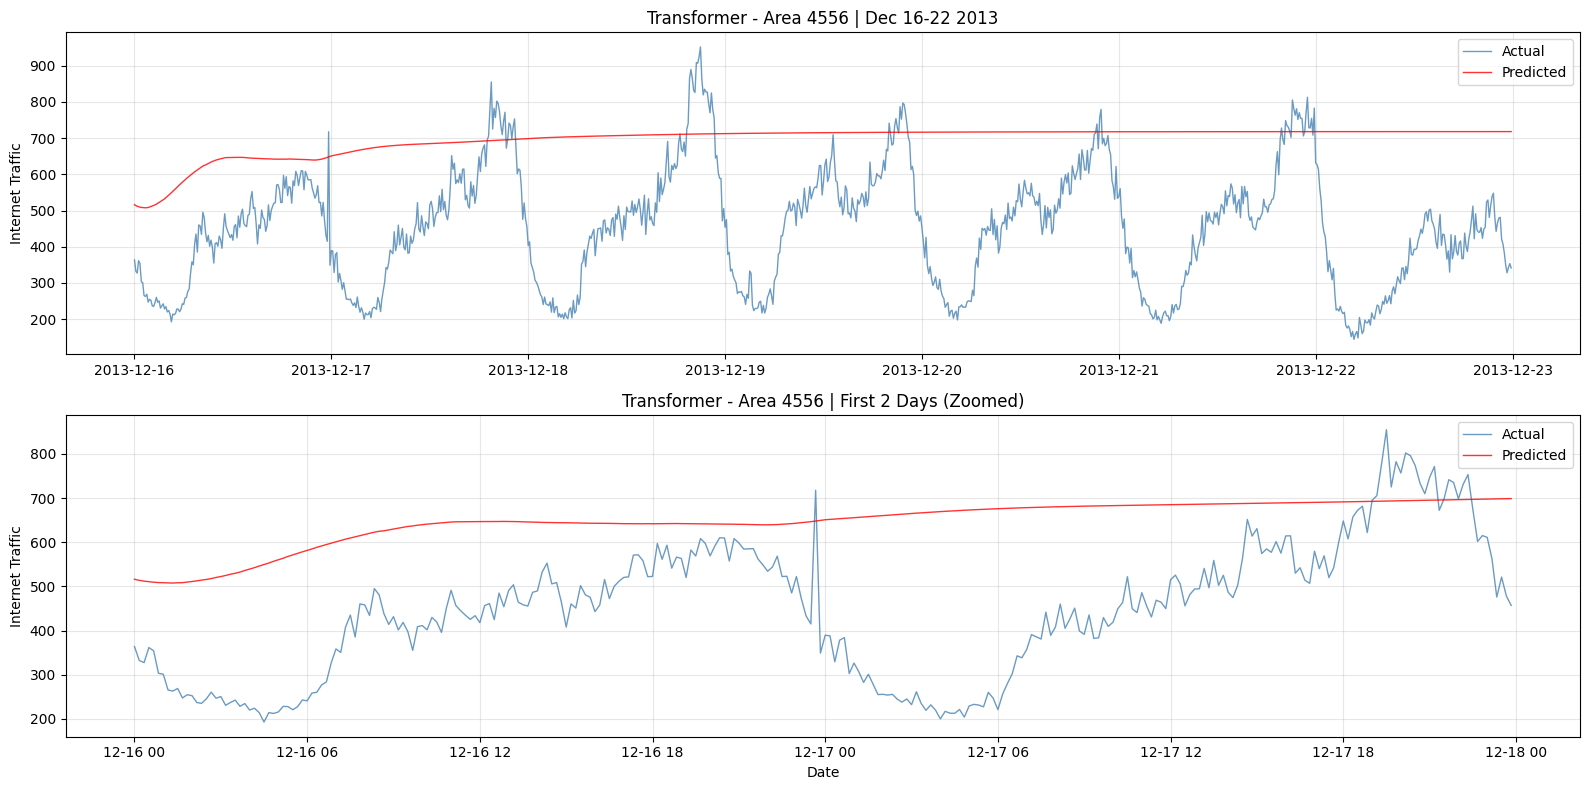

Plot saved: task3_transformer_area4556.png


In [9]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

TRANSFORMER_PATH = os.path.join(DATA_PATH, 'transformer_results.pkl')

def build_transformer(seq_len):
    inputs = tf.keras.Input(shape=(seq_len, 1))
    
    
    x = Dense(64)(inputs)
    
    
    attn = MultiHeadAttention(num_heads=4, key_dim=16)
    attn_out = attn(x, x)
    x = x + attn_out
    x = LayerNormalization()(x)
    
    # Feed forward block
    ff = Dense(128, activation='relu')(x)
    ff = Dense(64)(ff)
    x = x + ff
    x = LayerNormalization()(x)
    
    
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1)(x)
    
    return tf.keras.Model(inputs, outputs)

if os.path.exists(TRANSFORMER_PATH):
    print("Found saved Transformer results, loading...")
    with open(TRANSFORMER_PATH, 'rb') as f:
        transformer_results = pickle.load(f)
    print("Loaded!")

else:
    transformer_results = {}
    
    for area in target_areas:
        print(f"\nTraining Transformer for Area {area}...")
        train, test = prepare_series(area)
        
        # Normalize
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
        
        # Create sequences
        X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
        X_train = X_train.reshape(X_train.shape[0], SEQ_LEN, 1)
        
        # Build model
        model = build_transformer(SEQ_LEN)
        model.compile(optimizer='adam', loss='mse')
        
        callbacks = [
            EarlyStopping(patience=5, restore_best_weights=True),
            ReduceLROnPlateau(factor=0.5, patience=3)
        ]
        
        start_time = time.time()
        history = model.fit(
            X_train, y_train,
            epochs=30,
            batch_size=32,
            validation_split=0.1,
            callbacks=callbacks,
            verbose=1
        )
        train_time = time.time() - start_time
        
        # Rolling forecast
        print(f"  Forecasting {len(test)} steps...")
        start_pred = time.time()
        
        predictions = []
        current_seq = train_scaled[-SEQ_LEN:].copy()
        
        for _ in range(len(test)):
            x_input = current_seq.reshape(1, SEQ_LEN, 1)
            pred = model.predict(x_input, verbose=0)[0,0]
            predictions.append(pred)
            current_seq = np.roll(current_seq, -1)
            current_seq[-1] = pred
        
        pred_time = time.time() - start_pred
        
        # Inverse transform
        predictions = scaler.inverse_transform(
            np.array(predictions).reshape(-1,1)
        ).flatten()
        predictions = np.clip(predictions, 0, None)
        
        transformer_results[area] = {
            'predictions': predictions,
            'train_time': train_time,
            'pred_time': pred_time,
            'history': history.history
        }
        
        print(f"  Done! Train time: {train_time:.1f}s")
        
        model.save_weights(os.path.join(DATA_PATH, 
            f'transformer_weights_area{area}.weights.h5'))
        
        del model
        gc.collect()
    
    with open(TRANSFORMER_PATH, 'wb') as f:
        pickle.dump(transformer_results, f)
    print("\nTransformer results saved!")

print("TRANSFORMER RESULTS")

transformer_metrics = {}
for area in target_areas:
    train, test = prepare_series(area)
    preds = transformer_results[area]['predictions']
    
    metrics = evaluate_model(test.values, preds, 'Transformer', area)
    transformer_metrics[area] = metrics
    
    print(f"  Train time: {transformer_results[area]['train_time']:.1f}s")
    print(f"  Pred time:  {transformer_results[area]['pred_time']:.1f}s")
    
    plot_predictions(test.values, preds, area, 'Transformer', test.index)


In [12]:
print(f"{'Model':<15} {'MAE':>10} {'MAPE':>10} {'RMSE':>10} {'Train(s)':>10} {'Pred(s)':>10}")

for model_name, metrics, results in [
    ('SARIMA', sarima_metrics, sarima_results),
    ('LSTM', lstm_metrics, lstm_results),
    ('Transformer', transformer_metrics, transformer_results)
]:
    m = metrics[5161]
    print(f"{model_name:<15} {m['MAE']:>10.2f} {m['MAPE']:>9.2f}% "
          f"{m['RMSE']:>10.2f} {results[5161]['train_time']:>10.1f} "
          f"{results[5161]['pred_time']:>10.1f}")


print("FINAL RESULTS - AREA 4159 (Moderate Traffic)")
print(f"{'Model':<15} {'MAE':>10} {'MAPE':>10} {'RMSE':>10} {'Train(s)':>10} {'Pred(s)':>10}")
for model_name, metrics, results in [
    ('SARIMA', sarima_metrics, sarima_results),
    ('LSTM', lstm_metrics, lstm_results),
    ('Transformer', transformer_metrics, transformer_results)
]:
    m = metrics[4159]
    print(f"{model_name:<15} {m['MAE']:>10.2f} {m['MAPE']:>9.2f}% "
          f"{m['RMSE']:>10.2f} {results[4159]['train_time']:>10.1f} "
          f"{results[4159]['pred_time']:>10.1f}")


print("FINAL RESULTS - AREA 4556 (High Traffic)")

print(f"{'Model':<15} {'MAE':>10} {'MAPE':>10} {'RMSE':>10} {'Train(s)':>10} {'Pred(s)':>10}")

for model_name, metrics, results in [
    ('SARIMA', sarima_metrics, sarima_results),
    ('LSTM', lstm_metrics, lstm_results),
    ('Transformer', transformer_metrics, transformer_results)
]:
    m = metrics[4556]
    print(f"{model_name:<15} {m['MAE']:>10.2f} {m['MAPE']:>9.2f}% "
          f"{m['RMSE']:>10.2f} {results[4556]['train_time']:>10.1f} "
          f"{results[4556]['pred_time']:>10.1f}")


print("TRAINING TIME SUMMARY")

print(f"{'Model':<15} {'Area 5161':>12} {'Area 4159':>12} {'Area 4556':>12} {'Total':>12}")
for model_name, results in [
    ('SARIMA', sarima_results),
    ('LSTM', lstm_results),
    ('Transformer', transformer_results)
]:
    t1 = results[5161]['train_time']
    t2 = results[4159]['train_time']
    t3 = results[4556]['train_time']
    print(f"{model_name:<15} {t1:>11.1f}s {t2:>11.1f}s {t3:>11.1f}s {t1+t2+t3:>11.1f}s")

Model                  MAE       MAPE       RMSE   Train(s)    Pred(s)
SARIMA              354.70     20.16%     669.75     1146.7        2.2
LSTM               1843.35    436.31%    2220.78      238.0      147.6
Transformer        1155.95    201.38%    1459.54      403.2      184.6
FINAL RESULTS - AREA 4159 (Moderate Traffic)
Model                  MAE       MAPE       RMSE   Train(s)    Pred(s)
SARIMA              168.30     66.95%     195.90     1078.7        2.1
LSTM                112.31     35.63%     158.60      312.2      155.9
Transformer         113.30     36.10%     159.19      215.1      195.3
FINAL RESULTS - AREA 4556 (High Traffic)
Model                  MAE       MAPE       RMSE   Train(s)    Pred(s)
SARIMA              330.47     68.95%     377.15      687.6        2.9
LSTM                204.30     64.96%     240.94      620.9      147.4
Transformer         252.08     79.04%     290.05      103.1      197.6
TRAINING TIME SUMMARY
Model              Area 5161    Area 415

In [13]:
all_results = {
    'sarima_metrics': sarima_metrics,
    'lstm_metrics': lstm_metrics,
    'transformer_metrics': transformer_metrics,
    'sarima_results': sarima_results,
    'lstm_results': lstm_results,
    'transformer_results': transformer_results,
    'target_areas': target_areas
}

with open(os.path.join(DATA_PATH, 'all_results.pkl'), 'wb') as f:
    pickle.dump(all_results, f)

print(f"\nSummary:")
print(f"  Best for Area 5161: SARIMA (MAPE=20.16%)")
print(f"  Best for Area 4159: LSTM   (MAPE=35.63%)")
print(f"  Best for Area 4556: LSTM   (MAPE=64.96%)")
print(f"  Overall best model: LSTM")
print(f"  Fastest training:   Transformer")
print(f"  Most interpretable: SARIMA")


Summary:
  Best for Area 5161: SARIMA (MAPE=20.16%)
  Best for Area 4159: LSTM   (MAPE=35.63%)
  Best for Area 4556: LSTM   (MAPE=64.96%)
  Overall best model: LSTM
  Fastest training:   Transformer
  Most interpretable: SARIMA
